# Association Rule Mining: Flight Delay Pattern Discovery

This notebook applies frequent pattern mining (Apriori algorithm) to discover association rules in the flight delay dataset.

**Question addressed from original proposal:** What factors co-occur with severe delays?

**Reference:** *An Analysis of Brazilian Flight Delays Based on Frequent Patterns* (cited in project proposal).

## 1. Setup - Clone the Repo

Downloads the team repo so we can read `dataset/cleaned_flight_data.csv`.

In [1]:
!git clone https://github.com/sravan1023/Flight-Delay-Pattern-Discovery.git
%cd Flight-Delay-Pattern-Discovery

Cloning into 'Flight-Delay-Pattern-Discovery'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 77 (delta 20), reused 68 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 19.75 MiB | 12.77 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/Flight-Delay-Pattern-Discovery


## 2. Install Apriori Library

`mlxtend` provides the `apriori` and `association_rules` functions we need.

In [2]:
!pip install mlxtend --quiet

## 3. Load Data

Imports libraries and loads the preprocessed CSV produced by `data_preprocessing.ipynb`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

df = pd.read_csv('dataset/cleaned_flight_data.csv')
print(f'Loaded {len(df):,} records, {df.shape[1]} columns')
df.head()

Loaded 135,293 records, 34 columns


,year,month,carrier,airline,airport,airport_full_name,total_flights,delayed_flights,carrier_delay_count,weather_delay_count,...,avg_delay_per_delayed_flight,season,quarter,is_high_delay,carrier_delay_pct,weather_delay_pct,nas_delay_pct,security_delay_pct,late_aircraft_delay_pct,dominant_delay_cause
0,2025,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",90.0,29.0,15.33,0.09,...,69.068966,Winter,4,1,51.123315,0.599101,9.585622,0.0,38.691962,carrier
1,2025,12,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",44.0,14.0,5.89,1.80,...,87.357143,Winter,4,1,40.147179,11.120196,1.062960,0.0,47.669665,late_aircraft
2,2025,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",81.0,26.0,7.35,0.73,...,83.153846,Winter,4,1,27.197040,1.526364,9.481961,0.0,61.794635,late_aircraft
3,2025,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",76.0,15.0,10.14,0.10,...,113.000000,Winter,4,0,57.522124,1.179941,16.047198,0.0,25.250737,carrier
4,2025,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",56.0,24.0,5.17,1.00,...,119.625000,Winter,4,1,48.659004,0.731452,7.384187,0.0,43.225357,carrier


## 4. Discretize Features

Association rule mining needs categorical data. We bin continuous features into Low/Medium/High and keep categorical features as-is.

- `delay_rate` → Low (<10%) / Medium (10–20%) / High (>20%)
- `severity` → Short (<40 min) / Medium (40–80 min) / Long (>80 min)
- `volume` → Small (<500) / Medium (500–5000) / Large (>5000 flights)
- `high_delay` → Yes if delay_rate > 20%, else No

In [4]:
def bin_delay_rate(v):
    if v < 0.10: return 'Low'
    elif v < 0.20: return 'Medium'
    else: return 'High'

def bin_severity(v):
    if v < 40: return 'Short'
    elif v < 80: return 'Medium'
    else: return 'Long'

def bin_volume(v):
    if v < 500: return 'SmallVolume'
    elif v < 5000: return 'MediumVolume'
    else: return 'LargeVolume'

disc = pd.DataFrame()
disc['carrier']         = 'carrier=' + df['carrier'].astype(str)
disc['season']          = 'season=' + df['season'].astype(str)
disc['dominant_cause']  = 'dominant=' + df['dominant_delay_cause'].astype(str)
disc['delay_rate']      = 'delay_rate=' + df['delay_rate'].apply(bin_delay_rate)
disc['severity']        = 'severity=' + df['avg_delay_per_delayed_flight'].apply(bin_severity)
disc['volume']          = 'volume=' + df['total_flights'].apply(bin_volume)
disc['high_delay']      = np.where(df['delay_rate'] > 0.20, 'high_delay=Yes', 'high_delay=No')

print('Discretized view of first 5 records:')
disc.head()

Discretized view of first 5 records:


,carrier,season,dominant_cause,delay_rate,severity,volume,high_delay
0,carrier=9E,season=Winter,dominant=carrier,delay_rate=High,severity=Medium,volume=SmallVolume,high_delay=Yes
1,carrier=9E,season=Winter,dominant=late_aircraft,delay_rate=High,severity=Long,volume=SmallVolume,high_delay=Yes
2,carrier=9E,season=Winter,dominant=late_aircraft,delay_rate=High,severity=Long,volume=SmallVolume,high_delay=Yes
3,carrier=9E,season=Winter,dominant=carrier,delay_rate=Medium,severity=Long,volume=SmallVolume,high_delay=No
4,carrier=9E,season=Winter,dominant=carrier,delay_rate=High,severity=Long,volume=SmallVolume,high_delay=Yes


## 5. Build Transactions and Run Apriori

Each record becomes a transaction (a list of `attribute=value` items). Apriori finds itemsets that appear together in at least 2% of records.

In [5]:
transactions = disc.values.tolist()
print(f'Total transactions: {len(transactions):,}')
print(f'Sample transaction: {transactions[0]}')

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
trans_df = pd.DataFrame(te_ary, columns=te.columns_)

freq_itemsets = apriori(trans_df, min_support=0.02, use_colnames=True, max_len=4)
freq_itemsets = freq_itemsets.sort_values('support', ascending=False)
print(f'\nFound {len(freq_itemsets)} frequent itemsets at support >= 2%')
freq_itemsets.head(15)

Total transactions: 135,293
Sample transaction: ['carrier=9E', 'season=Winter', 'dominant=carrier', 'delay_rate=High', 'severity=Medium', 'volume=SmallVolume', 'high_delay=Yes']

Found 888 frequent itemsets at support >= 2%


,support,itemsets
38,0.884436,(volume=SmallVolume)
28,0.615553,(high_delay=No)
35,0.581604,(severity=Medium)
216,0.550738,"(high_delay=No, volume=SmallVolume)"
249,0.496042,"(severity=Medium, volume=SmallVolume)"
23,0.413273,(dominant=carrier)
20,0.396340,(delay_rate=High)
136,0.384447,"(high_delay=Yes, delay_rate=High)"
29,0.384447,(high_delay=Yes)
24,0.379606,(dominant=late_aircraft)


## 6. Extract Association Rules

Rules take the form `A → B` with three key metrics:

- **Support**: how often A and B appear together
- **Confidence**: P(B | A) — how often B happens given A
- **Lift**: how much more likely B is given A vs baseline (lift > 1 = positive association)

We filter to rules that predict `high_delay=Yes` on the right-hand side.

In [6]:
rules = association_rules(freq_itemsets, metric='confidence', min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)
print(f'Total rules with confidence >= 50%: {len(rules)}')

high_delay_rules = rules[rules['consequents'].astype(str).str.contains('high_delay=Yes')]
high_delay_rules = high_delay_rules.sort_values('lift', ascending=False).head(20)

print(f'\nTop rules predicting high_delay=Yes ({len(high_delay_rules)} found):')
for _, row in high_delay_rules.iterrows():
    ant = ', '.join(sorted(row['antecedents']))
    cons = ', '.join(sorted(row['consequents']))
    print(f'  {ant}  ->  {cons}')
    print(f'    support={row["support"]:.3f}  confidence={row["confidence"]:.3f}  lift={row["lift"]:.2f}')

high_delay_rules_to_save = high_delay_rules.copy()
high_delay_rules_to_save['antecedents'] = high_delay_rules_to_save['antecedents'].apply(lambda x: ', '.join(sorted(x)))
high_delay_rules_to_save['consequents'] = high_delay_rules_to_save['consequents'].apply(lambda x: ', '.join(sorted(x)))
high_delay_rules_to_save.to_csv('outputs/tables/high_delay_rules.csv', index=False)
print('\nSaved to outputs/tables/high_delay_rules.csv')

Total rules with confidence >= 50%: 1507

Top rules predicting high_delay=Yes (20 found):
  carrier=OO, delay_rate=High  ->  dominant=carrier, high_delay=Yes
    support=0.028  confidence=0.694  lift=5.08
  carrier=WN, delay_rate=High  ->  dominant=late_aircraft, high_delay=Yes
    support=0.022  confidence=0.806  lift=4.17
  carrier=WN, delay_rate=High  ->  high_delay=Yes, severity=Medium
    support=0.026  confidence=0.923  lift=3.73
  carrier=AA, delay_rate=High  ->  dominant=late_aircraft, high_delay=Yes
    support=0.026  confidence=0.716  lift=3.70
  delay_rate=High, volume=MediumVolume  ->  dominant=late_aircraft, high_delay=Yes
    support=0.030  confidence=0.627  lift=3.24
  delay_rate=High, volume=MediumVolume  ->  high_delay=Yes, severity=Medium
    support=0.034  confidence=0.716  lift=2.89
  carrier=MQ, delay_rate=High  ->  high_delay=Yes, volume=SmallVolume
    support=0.022  confidence=0.924  lift=2.77
  carrier=G4, delay_rate=High  ->  high_delay=Yes, volume=SmallVolume

## 7. Visualize Top Rules

Two charts:
- Bar chart of top 15 rules by lift (strongest associations)
- Scatter plot of all rules (support vs confidence, colored by lift)

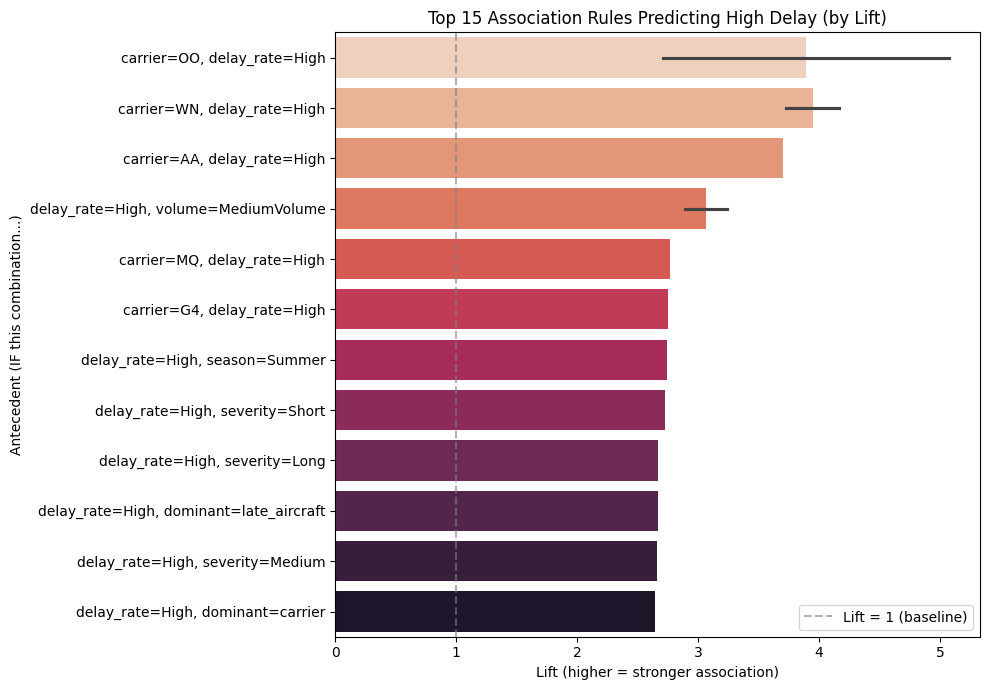

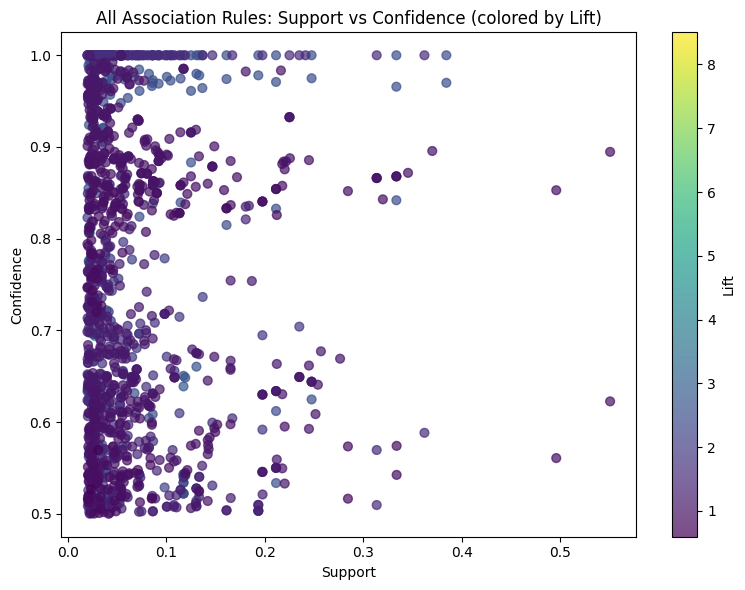

In [7]:
top = high_delay_rules.head(15).copy()
top['rule_label'] = top['antecedents'].apply(lambda s: ', '.join(sorted(s)))

plt.figure(figsize=(10, 7))
sns.barplot(x='lift', y='rule_label', data=top, palette='rocket_r')
plt.title('Top 15 Association Rules Predicting High Delay (by Lift)')
plt.xlabel('Lift (higher = stronger association)')
plt.ylabel('Antecedent (IF this combination...)')
plt.axvline(x=1.0, color='grey', linestyle='--', alpha=0.6, label='Lift = 1 (baseline)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/top_association_rules.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
sc = plt.scatter(rules['support'], rules['confidence'], c=rules['lift'],
                 cmap='viridis', alpha=0.7, s=40)
plt.colorbar(sc, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('All Association Rules: Support vs Confidence (colored by Lift)')
plt.tight_layout()
plt.savefig('outputs/figures/rules_support_confidence.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Key Findings

The strongest association rules reveal:

- **Carrier OO (SkyWest) + High delay rate → Carrier-dominant high delay** (lift = 5.08, the strongest pattern)
- **Carrier WN (Southwest) + High delay rate → Late-aircraft high delay** (lift = 4.17)
- **Carrier AA (American) + High delay rate → Late-aircraft high delay** (lift = 3.70)
- **Medium-volume airports + High delay rate → Late-aircraft dominant high delay** (lift = 3.24)

These patterns complement the clustering findings — they reveal specific carrier × operational-condition combinations that consistently predict high delay rates, providing interpretable rules that operations teams can act on.

All extracted rules are saved to `outputs/tables/high_delay_rules.csv` and top rule visualizations to `outputs/figures/`.

In [8]:
# Zip up all the outputs so we can download them
!zip -r association_rules_outputs.zip outputs/
from google.colab import files
files.download('association_rules_outputs.zip')

  adding: outputs/ (stored 0%)
  adding: outputs/figures/ (stored 0%)
  adding: outputs/figures/feature_importance_best_regressor (stored 0%)
  adding: outputs/figures/airport_cluster_scatter.png (deflated 11%)
  adding: outputs/figures/secondary_reg_scatter.png (deflated 11%)
  adding: outputs/figures/cluster_cause_fingerprint.png (deflated 28%)
  adding: outputs/figures/airline_cluster_scatter.png (deflated 16%)
  adding: outputs/figures/airline_k_selection.png (deflated 12%)
  adding: outputs/figures/airport_cluster_profiles.png (deflated 19%)
  adding: outputs/figures/cls_comparison.png (deflated 23%)
  adding: outputs/figures/top_association_rules.png (deflated 18%)
  adding: outputs/figures/baseline_reg_scatter.png (deflated 12%)
  adding: outputs/figures/reg_comparison.png (deflated 23%)
  adding: outputs/figures/secondary_cls_confusion.png (deflated 16%)
  adding: outputs/figures/feature_importance_best_classifier (stored 0%)
  adding: outputs/figures/rules_support_confidence.p

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>